Project #5: Video Stitching and Processing 

## CS445: Computational Photography - Spring 2020

### Setup


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# modify to where you store your project data including utils
datadir = "" 

utilfn = datadir + "utils.py"
!cp "$utilfn" .
imagesfn = datadir + "images"
!cp -r "$imagesfn" .

cp: ./utils.py and utils.py are identical (not copied).
cp: ./images and images are identical (not copied).


In [ ]:
!pip uninstall opencv-python -y
# downgrade OpenCV a bit to use SIFT
!pip install opencv-contrib-python==3.4.2.17 --force-reinstall
!pip install ffmpeg-python # for converting to video

import ffmpeg
import cv2
import numpy as np
import os
from numpy.linalg import svd, inv
import utils
%matplotlib inline
from matplotlib import pyplot as plt
import glob


ERROR: Could not find a version that satisfies the requirement opencv-contrib-python==3.4.2.17 (from versions: 3.4.11.45, 3.4.13.47, 3.4.14.51, 3.4.15.55, 3.4.16.59, 3.4.17.61, 3.4.17.63, 3.4.18.65, 4.4.0.46, 4.5.1.48, 4.5.2.52, 4.5.3.56, 4.5.4.58, 4.5.4.60, 4.5.5.62, 4.5.5.64, 4.6.0.66, 4.7.0.68, 4.7.0.72, 4.8.0.74, 4.8.0.76, 4.8.1.78, 4.9.0.80, 4.10.0.82, 4.10.0.84, 4.11.0.86, 4.12.0.88, 4.13.0.90, 4.13.0.92)
ERROR: No matching distribution found for opencv-contrib-python==3.4.2.17
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ffmpeg-python]0m [ffmpeg-python]


### Part I: Stitch two key frames 

#### This involves:
1. compute homography H between two frames; 
2. project each frame onto the same surface;
3. blend the surfaces.

Check that your homography is correct by plotting four points that form a square in frame 270 and their projections in each image.

In [4]:
def score_projection(pt1, pt2):
    '''
    Score corresponding to the number of inliers for RANSAC
    Input: pt1 and pt2 are 2xN arrays of N points such that pt1[:, i] and pt2[:,i] should be close in Euclidean distance if they are inliers
    Outputs: score (scalar count of inliers) and inliers (1xN logical array)
    '''
    threshold = 5.0  # pixel distance threshold for classifying inliers
    diff = pt1 - pt2
    distances = np.sqrt(np.sum(diff**2, axis=0))
    inliers = distances < threshold
    score = int(np.sum(inliers))
    return score, inliers


def auto_homography(Ia, Ib, homography_func=None, normalization_func=None):
    '''
    Computes a homography that maps points from Ia to Ib

    Input: Ia and Ib are images
    Output: H is the homography

    '''
    if Ia.dtype == 'float32' and Ib.dtype == 'float32':
        Ia = (Ia*255).astype(np.uint8)
        Ib = (Ib*255).astype(np.uint8)

    Ia_gray = cv2.cvtColor(Ia, cv2.COLOR_BGR2GRAY)
    Ib_gray = cv2.cvtColor(Ib, cv2.COLOR_BGR2GRAY)

    # Initiate SIFT detector
    sift = cv2.xfeatures2d.SIFT_create()

    # find the keypoints and descriptors with SIFT
    kp_a, des_a = sift.detectAndCompute(Ia_gray, None)
    kp_b, des_b = sift.detectAndCompute(Ib_gray, None)

    # BFMatcher with default params
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des_a, des_b, k=2)

    # Apply ratio test
    good = []
    for m, n in matches:
        if m.distance < 0.75*n.distance:
            good.append(m)

    numMatches = int(len(good))
    matches = good

    # Xa and Xb are 3xN matrices that contain homogeneous coordinates for the N
    # matching points for each image
    Xa = np.ones((3, numMatches))
    Xb = np.ones((3, numMatches))

    for idx, match_i in enumerate(matches):
        Xa[:, idx][0:2] = kp_a[match_i.queryIdx].pt
        Xb[:, idx][0:2] = kp_b[match_i.trainIdx].pt

    ## RANSAC
    niter = 1000
    best_score = 0
    n_to_sample = 4  # minimum number of point correspondences needed to solve for a homography

    H = None
    in_idx = None

    for t in range(niter):
        # estimate homography
        subset = np.random.choice(numMatches, n_to_sample, replace=False)
        pts1 = Xa[:, subset]
        pts2 = Xb[:, subset]

        H_t = homography_func(pts1, pts2, normalization_func)

        # score homography
        Xb_ = np.dot(H_t, Xa)  # project points from first image to second using H

        score_t, inliers_t = score_projection(Xb[:2, :]/Xb[2, :], Xb_[:2, :]/Xb_[2, :])

        if score_t > best_score:
            best_score = score_t
            H = H_t
            in_idx = inliers_t

    print('best score: {:02f}'.format(best_score))

    # Re-estimate H using all inliers for a more accurate result
    if in_idx is not None and np.sum(in_idx) >= n_to_sample:
        H = homography_func(Xa[:, in_idx], Xb[:, in_idx], normalization_func)
        print('Re-estimated H using {:d} inliers'.format(int(np.sum(in_idx))))

    return H

In [8]:
def computeHomography(pts1, pts2, normalization_func=None):
    '''
    Compute homography that maps from pts1 to pts2 using SVD. Normalization is optional.

    Input: pts1 and pts2 are 3xN matrices for N points in homogeneous coordinates.
    Output: H is a 3x3 matrix, such that pts2~=H*pts1
    '''
    N = pts1.shape[1]

    # Convert to inhomogeneous coordinates
    x1 = pts1[0, :] / pts1[2, :]
    y1 = pts1[1, :] / pts1[2, :]
    x2 = pts2[0, :] / pts2[2, :]
    y2 = pts2[1, :] / pts2[2, :]

    # Build the 2N x 9 matrix A such that Ah = 0
    A = np.zeros((2 * N, 9))
    for i in range(N):
        A[2*i]     = [-x1[i], -y1[i], -1,      0,      0,  0, x2[i]*x1[i], x2[i]*y1[i], x2[i]]
        A[2*i + 1] = [     0,      0,  0, -x1[i], -y1[i], -1, y2[i]*x1[i], y2[i]*y1[i], y2[i]]

    # Solve Ah = 0 via SVD; solution is the last row of Vh (right singular vector for smallest singular value)
    U, S, Vh = np.linalg.svd(A)
    h = Vh[-1, :]
    H = h.reshape(3, 3)

    return H


best score: 221.000000
Re-estimated H using 221 inliers
H (normalized):
[[ 1.00000000e+00  4.17919845e-02 -2.04154869e+02]
 [ 1.14205543e-02  9.45588751e-01 -1.44319874e+01]
 [ 3.63056146e-04  2.85885437e-05  8.21427777e-01]]


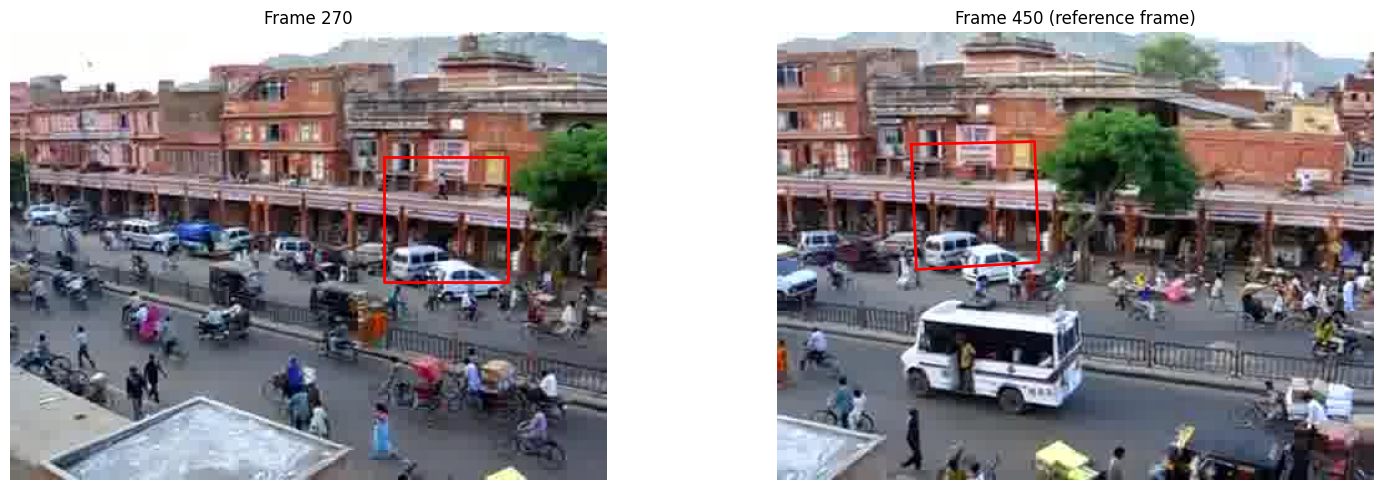

Saved: part1_box_projection.png


In [10]:
# images location
im1_path = './images/input/frames/f0270.jpg'
im2_path = './images/input/frames/f0450.jpg'

# Load images (OpenCV loads as BGR)
im1 = cv2.imread(im1_path)
im2 = cv2.imread(im2_path)

H = auto_homography(im1, im2, computeHomography)
print("H (normalized):")
print(H / H.max())

# Define a square in frame 270 using homogeneous coordinates
box_pts = np.array([[300, 400, 400, 300, 300],
                    [100, 100, 200, 200, 100],
                    [  1,   1,   1,   1,   1]], dtype=float)

# Plot the box in frame 270 (im1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(im1[:, :, [2, 1, 0]])
axes[0].plot(box_pts[0, :], box_pts[1, :], 'r-', linewidth=2)
axes[0].set_title('Frame 270')
axes[0].axis('off')

# Project box_pts from frame 270 into the reference frame 450 using homography H
box_pts_proj = H @ box_pts
box_pts_proj = box_pts_proj / box_pts_proj[2, :]  # convert back from homogeneous

# Plot the projected box in frame 450 (im2)
axes[1].imshow(im2[:, :, [2, 1, 0]])
axes[1].plot(box_pts_proj[0, :], box_pts_proj[1, :], 'r-', linewidth=2)
axes[1].set_title('Frame 450 (reference frame)')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('part1_box_projection.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: part1_box_projection.png")



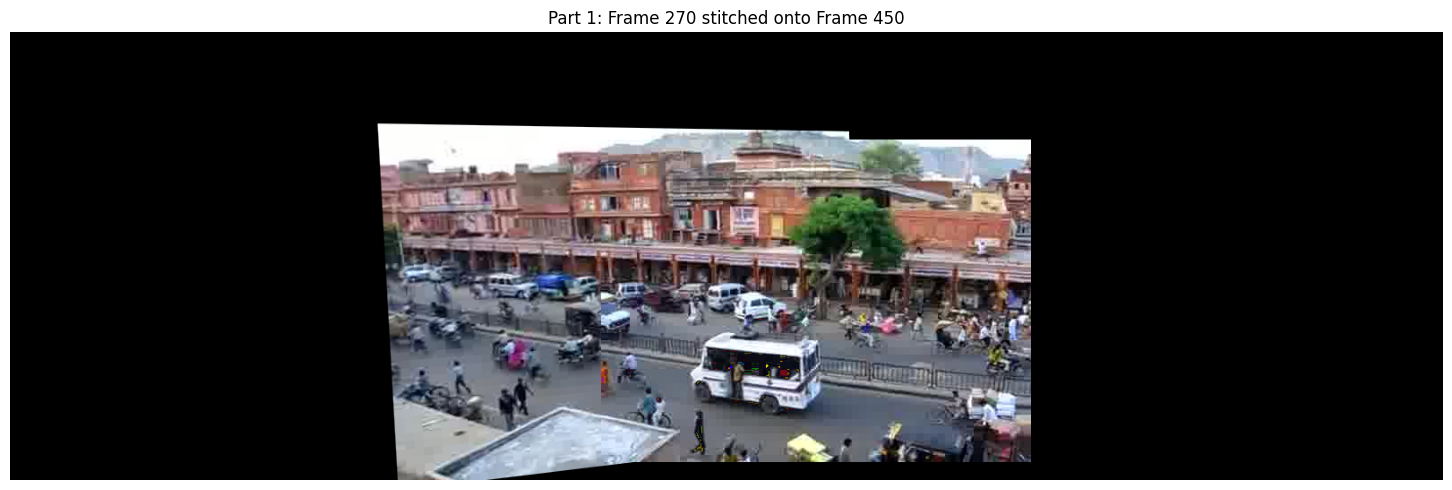

Saved: part1_stitched.png


In [7]:
projectedWidth = 1600
projectedHeight = 500

# Translation matrix that shifts the reference frame (450) to roughly the center of the panorama
Tr = np.array([[1, 0, 660],
               [0, 1, 120],
               [0, 0,   1]], dtype=float)

# Project frame 450 (reference) to the panorama using only the translation
projIm2 = cv2.warpPerspective(im2, Tr, (projectedWidth, projectedHeight))

# Project frame 270 (source) to the panorama: first H maps im1->im2, then Tr shifts to panorama
H_adjusted = Tr @ H
projIm1 = cv2.warpPerspective(im1, H_adjusted, (projectedWidth, projectedHeight))

# Blend: fill zero pixels in the reference projection with pixels from the source projection
blended = utils.blendImages(projIm1, projIm2)

# Display result (convert BGR -> RGB for matplotlib)
plt.figure(figsize=(16, 5))
plt.imshow(blended[:, :, [2, 1, 0]])
plt.title('Part 1: Frame 270 stitched onto Frame 450')
plt.axis('off')
plt.tight_layout()
plt.savefig('part1_stitched.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: part1_stitched.png")




### Part II: Panorama using five key frames

Produce a panorama by mapping five key frames [90, 270, 450, 630, 810] onto the same reference frame 450.  


Computing H: f630 -> f450
best score: 214.000000
Re-estimated H using 214 inliers
Computing H: f90 -> f270
best score: 258.000000
Re-estimated H using 258 inliers
Computing H: f810 -> f630
best score: 151.000000
Re-estimated H using 151 inliers


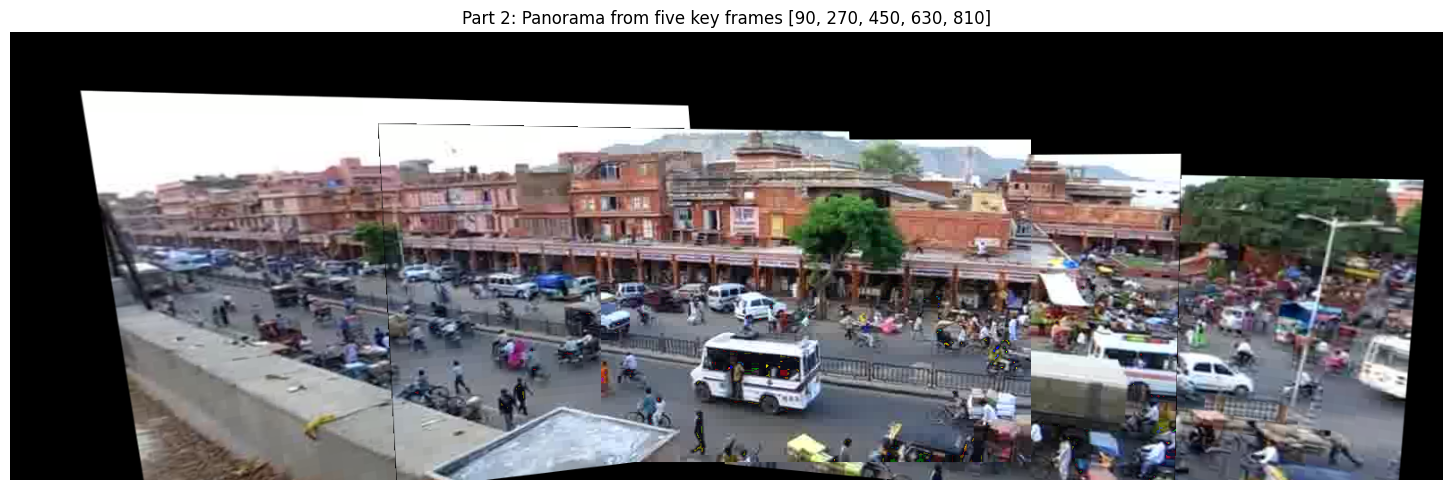

Saved: part2_panorama.png


In [ ]:
key_frame_nums = [90, 270, 450, 630, 810]  # 1-based frame numbers

# Load the five key frames
kf = {}
for num in key_frame_nums:
    kf[num] = cv2.imread('./images/input/frames/f{:04d}.jpg'.format(num))

# Compute direct homographies to the reference frame 450
# H_270_450 was already computed in Part 1 as H (im1=f270, im2=f450)
H_270_450 = H  # maps f270 -> f450

print("Computing H: f630 -> f450")
H_630_450 = auto_homography(kf[630], kf[450], computeHomography)

# Compute intermediate homographies for frames too far from f450
print("Computing H: f90 -> f270")
H_90_270 = auto_homography(kf[90], kf[270], computeHomography)

print("Computing H: f810 -> f630")
H_810_630 = auto_homography(kf[810], kf[630], computeHomography)

# Chain homographies for frames 90 and 810
# f90 -> f270 -> f450: apply H_90_270 first, then H_270_450
H_90_450  = H_270_450 @ H_90_270

# f810 -> f630 -> f450: apply H_810_630 first, then H_630_450
H_810_450 = H_630_450 @ H_810_630

# Map everything to panorama space using Tr
projectedWidth  = 1600
projectedHeight = 500
Tr = np.array([[1, 0, 660],
               [0, 1, 120],
               [0, 0,   1]], dtype=float)

# Homographies from each key frame to the panorama (Tr @ H_X_450)
H_to_pano = {
    90:  Tr @ H_90_450,
    270: Tr @ H_270_450,
    450: Tr,                  # reference frame: only translation
    630: Tr @ H_630_450,
    810: Tr @ H_810_450,
}

# Warp each key frame into the panorama
warped = {}
for num in key_frame_nums:
    warped[num] = cv2.warpPerspective(kf[num], H_to_pano[num],
                                      (projectedWidth, projectedHeight))

# Blend all five warped frames into a single panorama.
# Start with f450 (reference) and layer the others on top by filling zero pixels.
panorama = warped[450].copy()
for num in [270, 630, 90, 810]:   # add adjacent frames first, then the far ones
    panorama = utils.blendImages(warped[num], panorama)

# Display
plt.figure(figsize=(16, 5))
plt.imshow(panorama[:, :, [2, 1, 0]])
plt.title('Part 2: Panorama from five key frames [90, 270, 450, 630, 810]')
plt.axis('off')
plt.tight_layout()
plt.savefig('part2_panorama.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: part2_panorama.png")




### Part 3: Map the video to the reference plane

Project each frame onto the reference frame (using same size panorama) to create a video that shows the portion of the panorama revealed by each frame

In [30]:
# read all the images
dir_frames = 'images/input/frames'
filenames = []
filesinfo = os.scandir(dir_frames)

filenames = [f.path for f in filesinfo if f.name.endswith(".jpg")]
filenames.sort(key=lambda f: int(''.join(filter(str.isdigit, f))))

frameCount = len(filenames)
frameHeight, frameWidth, frameChannels = cv2.imread(filenames[0]).shape
frames = np.zeros((frameCount, frameHeight, frameWidth, frameChannels),dtype='uint8')

for idx, file_i in enumerate(filenames):
  frames[idx] = cv2.imread(file_i)



In [ ]:
# Output directories
os.makedirs('images/output/part3_frames', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Key frame homographies to the panorama (computed in Part 2) 
# H_kf_to_450[kf_num] maps that key frame into the reference frame 450's plane.
# Chaining with Tr gives the direct mapping to panorama coordinates.
H_kf_to_450 = {
     90: H_90_450,
    270: H_270_450,
    450: np.eye(3),   # reference frame maps to itself
    630: H_630_450,
    810: H_810_450,
}

# Assign each 1-based frame number to its nearest key frame.
# Boundaries sit at midpoints between consecutive key frames.
def nearest_key_frame(frame_num):
    boundaries = [180, 360, 540, 720]  # midpoints between [90,270,450,630,810]
    kfs = [90, 270, 450, 630, 810]
    for i, b in enumerate(boundaries):
        if frame_num <= b:
            return kfs[i]
    return kfs[-1]

# Compute per-frame homographies and warp 
H_all = np.zeros((frameCount, 3, 3), dtype=np.float64)

for idx in range(frameCount):
    frame_num = idx + 1          # 1-based
    nkf = nearest_key_frame(frame_num)
    frame_img = frames[idx]

    if frame_num == nkf:
        # Key frame itself: reuse precomputed homography
        H_frame_to_pano = Tr @ H_kf_to_450[nkf]
    else:
        # Compute H from this frame to its nearest key frame
        H_frame_to_kf = auto_homography(frame_img, kf[nkf], computeHomography)
        # Chain: frame -> nearest_kf -> f450 -> panorama
        H_frame_to_pano = Tr @ H_kf_to_450[nkf] @ H_frame_to_kf

    H_all[idx] = H_frame_to_pano

    # Warp and save to disk (saves memory vs. holding 900 warped frames)
    warped_frame = cv2.warpPerspective(frame_img, H_frame_to_pano,
                                       (projectedWidth, projectedHeight))
    out_path = 'images/output/part3_frames/a{:04d}.jpg'.format(idx + 1)
    cv2.imwrite(out_path, warped_frame)

    if (idx + 1) % 50 == 0 or idx == 0:
        print(f'Frame {frame_num:3d}/{frameCount}  nearest_kf={nkf}  saved {out_path}')

# Save all homographies for use in Parts 4-6
np.save('results/H_all.npy', H_all)
print(f'\nSaved H_all.npy  shape={H_all.shape}')
print('Warped frames written to images/output/part3_frames/')

# Compile warped frames into a video using utils.imageFolder2mpeg 
out_video = 'results/part3_video.mpeg'
utils.imageFolder2mpeg('images/output/part3_frames', out_video, fps=30.0)
print(f'Video saved: {out_video}')

best score: 429.000000
Re-estimated H using 429 inliers
Frame   1/900  nearest_kf=90  saved images/output/part3_frames/a0001.jpg
best score: 429.000000
Re-estimated H using 429 inliers
best score: 453.000000
Re-estimated H using 453 inliers
best score: 443.000000
Re-estimated H using 443 inliers
best score: 462.000000
Re-estimated H using 462 inliers
best score: 450.000000
Re-estimated H using 450 inliers
best score: 481.000000
Re-estimated H using 481 inliers


/var/folders/ks/rw1mx1zj0pq2gy63k5z3g1840000gn/T/ipykernel_14861/328022978.py:78: RuntimeWarning: divide by zero encountered in divide
  score_t, inliers_t = score_projection(Xb[:2, :]/Xb[2, :], Xb_[:2, :]/Xb_[2, :])


best score: 457.000000
Re-estimated H using 457 inliers
best score: 476.000000
Re-estimated H using 476 inliers
best score: 495.000000
Re-estimated H using 495 inliers
best score: 494.000000
Re-estimated H using 494 inliers
best score: 480.000000
Re-estimated H using 480 inliers
best score: 494.000000
Re-estimated H using 494 inliers
best score: 479.000000
Re-estimated H using 479 inliers
best score: 508.000000
Re-estimated H using 508 inliers
best score: 505.000000
Re-estimated H using 505 inliers
best score: 517.000000
Re-estimated H using 517 inliers
best score: 507.000000
Re-estimated H using 507 inliers
best score: 491.000000
Re-estimated H using 491 inliers
best score: 496.000000
Re-estimated H using 496 inliers
best score: 480.000000
Re-estimated H using 480 inliers
best score: 491.000000
Re-estimated H using 491 inliers
best score: 505.000000
Re-estimated H using 505 inliers
best score: 494.000000
Re-estimated H using 494 inliers
best score: 518.000000
Re-estimated H using 518 

OpenCV: FFMPEG: tag 0x3147504d/'MPG1' is not supported with codec id 1 and format 'mpeg / MPEG-1 Systems / MPEG program stream'


Video saved: results/part3_video.mpeg


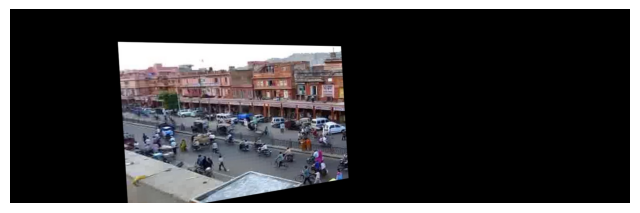

In [34]:
# Frame 200 of the video
frame_200 = cv2.imread('images/output/part3_frames/a0200.jpg')
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(frame_200, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Part 4: Create background panorama

Create a background panorama based on the result from Part 3.


Found 900 warped frames
Panorama size: 1600 x 500
Loading all warped frames into memory…
  Loaded 100/900
  Loaded 200/900
  Loaded 300/900
  Loaded 400/900
  Loaded 500/900
  Loaded 600/900
  Loaded 700/900
  Loaded 800/900
  Loaded 900/900
Computing pixel-wise median (excluding no-data pixels)…


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Done.
Background panorama saved: results/part4_background.jpg


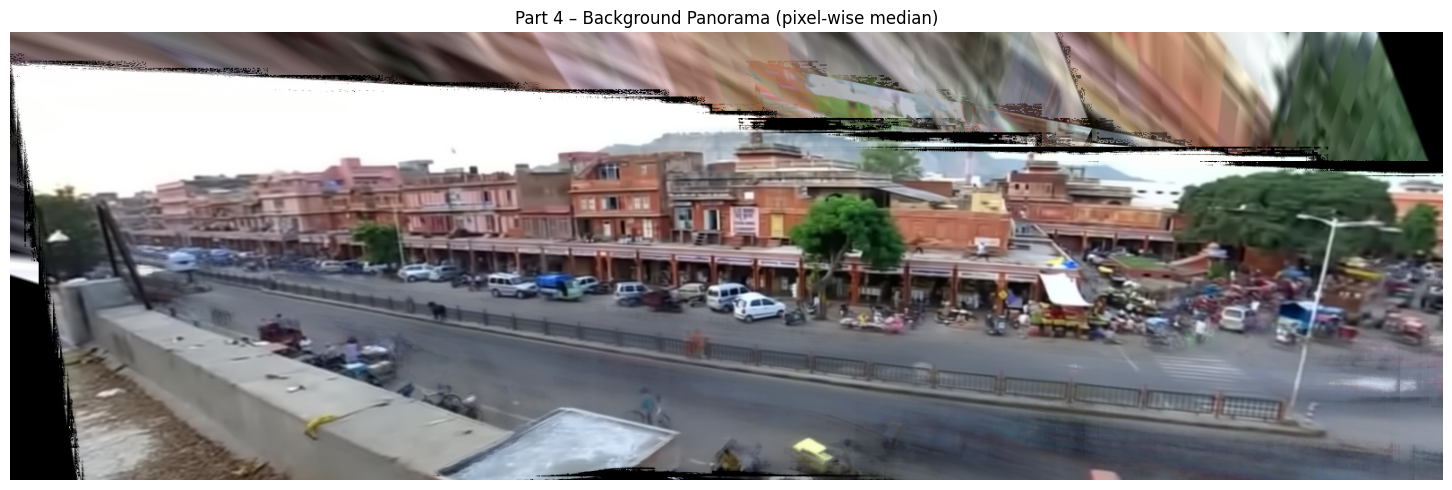

In [ ]:
# Part 4: Create background panorama
#
# Strategy: pixel-wise median across all warped frames.
# Black pixels (0,0,0) in a warped frame mean "no data" for that pixel
# (outside the frame's footprint), so we exclude them before computing
# the median.  Background pixels are stable across frames; foreground
# objects are transient and get suppressed by the median.

import glob, os


# 1. Collect all warped frames
part3_dir = 'images/output/part3_frames'
frame_paths = sorted(glob.glob(os.path.join(part3_dir, 'a*.jpg')))
n_frames = len(frame_paths)
print(f'Found {n_frames} warped frames')

# Read one frame to get panorama dimensions
sample = cv2.imread(frame_paths[0])
pano_h, pano_w = sample.shape[:2]
print(f'Panorama size: {pano_w} x {pano_h}')

# 2. Accumulate per-pixel color samples
# We process one channel at a time to keep peak memory reasonable.
# For each pixel we want the median of only the frames that actually
# cover that pixel (i.e. where the warped value is not pure black).
#
# Approach: load all frames into a (N, H, W, 3) uint8 array.
# For 900 frames at 500×1600 this is ~2.2 GB – manageable on most machines.
# If memory is tight, switch to the chunk-based fallback below.

print('Loading all warped frames into memory…')
all_frames = np.zeros((n_frames, pano_h, pano_w, 3), dtype=np.uint8)
for i, p in enumerate(frame_paths):
    all_frames[i] = cv2.imread(p)          # BGR, shape (H, W, 3)
    if (i + 1) % 100 == 0:
        print(f'  Loaded {i+1}/{n_frames}')

print('Computing pixel-wise median (excluding no-data pixels)…')

# Build a validity mask: a pixel is valid if it is NOT pure black.
# Shape: (N, H, W)  – True where the frame has real data.
valid = all_frames.any(axis=3)             # True if any channel != 0

# For pixels that are NEVER covered by any frame, fall back to black.
# For all other pixels, compute the median over valid frames only.
background = np.zeros((pano_h, pano_w, 3), dtype=np.uint8)

# Process channel by channel to reuse the valid mask
for ch in range(3):
    channel = all_frames[:, :, :, ch].astype(np.float32)   # (N, H, W)
    # Replace invalid samples with NaN so nanmedian ignores them
    channel[~valid] = np.nan
    # nanmedian over axis 0 → (H, W)
    med = np.nanmedian(channel, axis=0)
    # Where every frame was invalid (all NaN), nanmedian returns NaN → keep 0
    med = np.nan_to_num(med, nan=0.0)
    background[:, :, ch] = np.clip(med, 0, 255).astype(np.uint8)

print('Done.')

# 3. Save and display
os.makedirs('results', exist_ok=True)
bg_path = 'results/part4_background.jpg'
cv2.imwrite(bg_path, background)
print(f'Background panorama saved: {bg_path}')

plt.figure(figsize=(16, 5))
plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
plt.title('Part 4 – Background Panorama (pixel-wise median)')
plt.axis('off')
plt.tight_layout()
plt.show()


### Part 5: Create background movie

Generate a movie that looks like the input movie but shows only background pixels. For each frame of the movie, you need to estimate a projection from the panorama to that frame. Your solution can use the background image you created in Part 4 and the per-frame homographies you created in Part 3. 


In [ ]:
# TO DO part 5



### Part 6: Create foreground movie

In the background video, moving objects are removed. In each frame, those pixels that are different enough than the background color are considered foreground. For each frame determine foreground pixels and generate a movie that emphasizes or includes only foreground pixels.

In [ ]:
# TO DO part 6


## Bells and whistles